In [3]:
import os
os.sys.path.append('/data/scratch/globc/bonassies/workspace/swot_for_flood')
import geopandas as gpd
import configparser
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
from cmap import Colormap

from core.swot_project import SwotProject
from core.plot_raster import PlotRaster
import cartopy
from matplotlib.lines import Line2D

In [4]:
def add_arrow_range(ax, test_case):
    match test_case:

        case "Greece":
            ax.annotate(
                "",
                xy=(0.05, 1.07),  # position of the arrow
                xytext=(0.15, 1.1),  # position of the text
                size=20,
                xycoords="axes fraction",
                textcoords="axes fraction",
                arrowprops=dict(
                    arrowstyle="->",
                    color="black",
                    lw=2,
                )   
            )
            ax.annotate("Near Range", xy=(0.1, 1.2), xytext=(0.1, 1.2), xycoords="axes fraction", textcoords="axes fraction", fontsize=20, ha="center", va="center")

            ax.annotate(
                "",
                xy=(0.95, -0.07),  # position of the text
                xytext=(0.85, -.1),  # position of the arrow
                size=20,
                xycoords="axes fraction",
                textcoords="axes fraction",
                arrowprops=dict(
                    arrowstyle="->",
                    color="black",
                    lw=2,
                )   
            )
            ax.annotate("Far Range", xy=(0.9, -.2), xytext=(0.9, -.2), xycoords="axes fraction", textcoords="axes fraction", fontsize=20, ha="center", va="center")

        case "Chinon" | "Ohio":
            ax.annotate(
                "",
                xy=(0.95, -0.1),  # position of the text
                xytext=(0.85, -.07),  # position of the arrow
                size=20,
                xycoords="axes fraction",
                textcoords="axes fraction",
                arrowprops=dict(
                    arrowstyle="->",
                    color="black",
                    lw=2,
                )   
            )
            ax.annotate("Near Range", xy=(0.9, -.2), xytext=(0.9, -.2), xycoords="axes fraction", textcoords="axes fraction", fontsize=20, ha="center", va="center")

            ax.annotate(
                "",
                xy=(0.05, 1.1),  # position of the arrow
                xytext=(0.15, 1.07),  # position of the text
                size=20,
                xycoords="axes fraction",
                textcoords="axes fraction",
                arrowprops=dict(
                    arrowstyle="->",
                    color="black",
                    lw=2,
                )   
            )
            ax.annotate("Far Range", xy=(0.1, 1.2), xytext=(0.1, 1.2), xycoords="axes fraction", textcoords="axes fraction", fontsize=20, ha="center", va="center")

        case "PortoAlegre":
            ax.annotate(
                "",
                xy=(0.05, 1.1),  # position of the arrow
                xytext=(0.15, 1.07),  # position of the text
                size=20,
                xycoords="axes fraction",
                textcoords="axes fraction",
                arrowprops=dict(
                    arrowstyle="->",
                    color="black",
                    lw=2,
                )   
            )
            ax.annotate("Near Range", xy=(0.1, 1.2), xytext=(0.1, 1.2), xycoords="axes fraction", textcoords="axes fraction", fontsize=20, ha="center", va="center")

            ax.annotate(
                "",
                xy=(0.95, -0.1),  # position of the text
                xytext=(0.85, -.07),  # position of the arrow
                size=20,
                xycoords="axes fraction",
                textcoords="axes fraction",
                arrowprops=dict(
                    arrowstyle="->",
                    color="black",
                    lw=2,
                )   
            )
            ax.annotate("Far Range", xy=(0.9, -.2), xytext=(0.9, -.2), xycoords="axes fraction", textcoords="axes fraction", fontsize=20, ha="center", va="center")



def plot_polygons(plot_obj,ax):
    # polygon_control = plot_obj.swot_collection.controlmask
    polygon_flood = plot_obj.swot_collection.floodmask
    # set crs to WGS84
    # polygon_control = polygon_control.to_crs(4326)
    polygon_flood = polygon_flood.to_crs(4326)
    # plot the polygons
    # polygon_control.plot(ax=ax, color="none", edgecolor="black", linewidth=1)
    polygon_flood.plot(ax=ax, color='blue', alpha=0.5, linewidth=1)

# Plotting for subplot of all projects

This notebook uses the rasters generated in all project to plot the results of exercises. The rasters are stored in the `rasters` folder and the plots are stored in the `plots` folder.

First, we need to load the project:

In [5]:
Ohio_config = configparser.ConfigParser()
Ohio_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Ohio"
Ohio_config.read(Ohio_path + '/config.cfg')
Ohio_project = SwotProject(Ohio_config)
Ohio_project.find_raster()

Chinon_config = configparser.ConfigParser()
Chinon_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon"
Chinon_config.read(Chinon_path + '/config.cfg')
Chinon_project = SwotProject(Chinon_config)
Chinon_project.find_raster()

EMSR692_config = configparser.ConfigParser()
EMSR692_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/EMSR_692"
EMSR692_config.read(EMSR692_path + '/config.cfg')
EMSR692_project = SwotProject(EMSR692_config)
EMSR692_project.find_raster()

PortoAlegre_config = configparser.ConfigParser()
PortoAlegre_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre"
PortoAlegre_config.read(PortoAlegre_path + '/config.cfg')
PortoAlegre_project = SwotProject(PortoAlegre_config)
PortoAlegre_project.find_raster()

Data path already exists in /data/scratch/globc/bonassies/data or download is set to False
SWOT data already exists in /data/scratch/globc/bonassies/data/SWOT or download is set to False
SWOT project already exists in /data/scratch/globc/bonassies/data/SWOT/Ohio or download is set to False
Geopackage already exists in /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Ohio/gpkg_combined or make_gpkg is set to False
TIFF path already exists in /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Ohio/rasters or make_tiff is set to False
No automatic download, please use the Downloader object to download the data
Data path already exists in /data/scratch/globc/bonassies/data or download is set to False
SWOT data already exists in /data/scratch/globc/bonassies/data/SWOT or download is set to False
SWOT project already exists in /data/scratch/globc/bonassies/data/SWOT/Chinon or download is set to False
Geopackage already exists in /data/scratch/globc/bonassies/works

Then, once loaded, we need to create, load and pre-treat the SWOT data used for plotting.
Here we use the collection object within the project to create a new collection with the dry and flooded times selected.

In [6]:
# from time import time
# start = time()
# print(">>> Opening Chinon raster files")
# Chinon_project.create_collection()
# print("Elapsed time: ", time() - start)

# Chinon_plot : PlotRaster = PlotRaster(
#     Chinon_project,
#     save_fig=False,
#     show_fig=True
#     )

In [7]:
from time import time
start0 = time()
print(">>> Opening Porto Alegre raster files")
PortoAlegre_project.create_collection()
print("Elapsed time: ", time() - start0)

start = time()
print(">>> Opening Ohio raster files")
Ohio_project.create_collection()
print("Elapsed time: ", time() - start)

start = time()
print(">>> Opening Chinon raster files")
Chinon_project.create_collection()
print("Elapsed time: ", time() - start)

start = time()
print(">>> Opening EMSR 692 raster files")
EMSR692_project.create_collection()
print("Elapsed time: ", time() - start)
print("Total elapsed time: ", time() - start0)

>>> Opening Porto Alegre raster files
Opening SWOT raster at time: 2024-05-06 11:46:43


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Opening SWOT raster at time: 2024-03-25 18:16:34


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Opening SWOT raster at time: 2024-04-15 15:01:40


...

Opening SWOT raster at time: 2024-08-24 16:31:44


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Opening SWOT raster at time: 2024-08-03 19:46:40


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Elapsed time:  13.843554258346558
>>> Opening EMSR 692 raster files
Opening SWOT raster at time: 2023-09-15 07:08:16
Opening SWOT raster at time: 2024-07-03 09:39:20
Opening SWOT raster at time: 2024-07-24 06:24:25
Opening SWOT raster at time: 2024-05-01 19:24:16
Opening SWOT raster at time: 2024-04-10 22:39:02
Elapsed time:  75.43050217628479
Total elapsed time:  220.64585971832275


We can then create the plot object that we will use to plot the data.

In [8]:
Ohio_plot : PlotRaster = PlotRaster(
    Ohio_project,
    save_fig=False,
    show_fig=False
    )

PortoAlegre_plot : PlotRaster = PlotRaster(
    PortoAlegre_project,
    save_fig=False,
    show_fig=False
    )

Chinon_plot : PlotRaster = PlotRaster(
    Chinon_project,
    save_fig=False,
    show_fig=False
    )

EMSR692_plot : PlotRaster = PlotRaster(
    EMSR692_project,
    save_fig=False,
    show_fig=False
    )

# S1 and S2 subplots

## Floodmask

In [9]:
# max width = 2244 pixels
# figsize = (12, 8)
# dpi = 300
# figsize = (2244 / dpi, 2244 / dpi * 8 / 12)

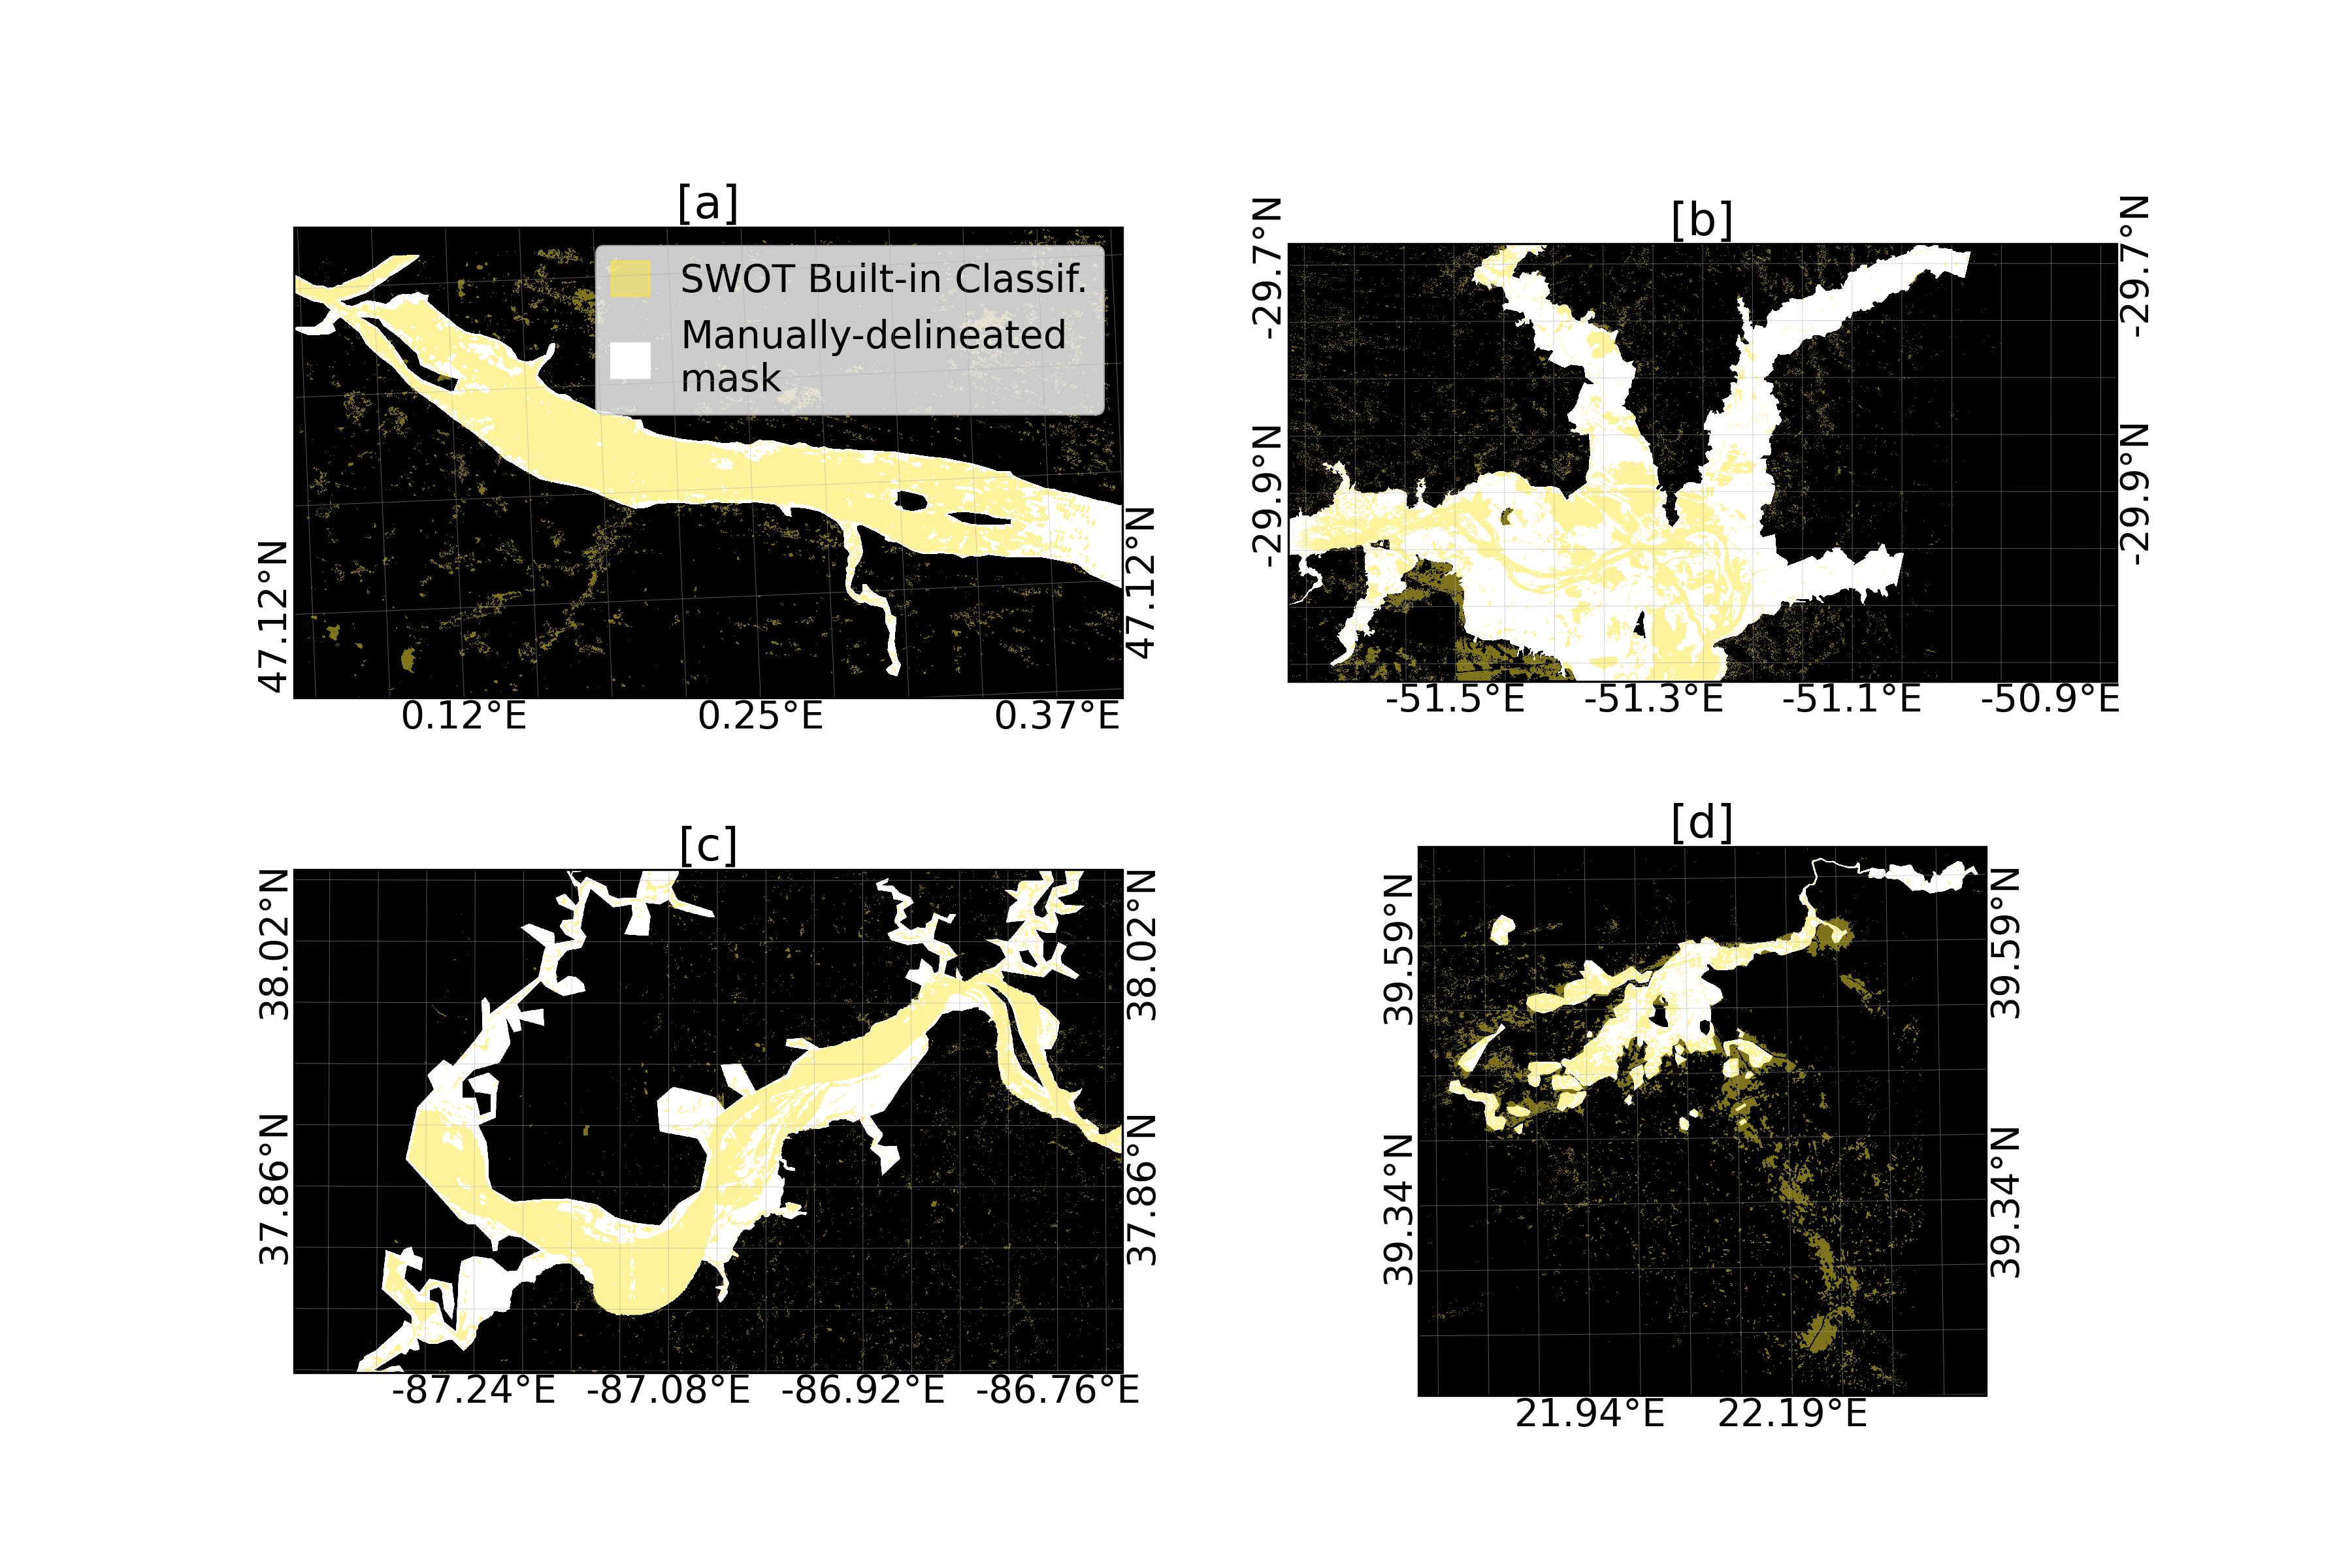

In [12]:
dpi = 2244 / 12
fig, ax = plt.subplots(2, 2, figsize=(12,8), dpi=300,
                        subplot_kw={'projection': (cartopy.crs.PlateCarree())})
                        

ax[0, 0].remove()
ax[0, 1].remove()
ax[1, 0].remove()
ax[1, 1].remove()

path_aux_Ohio = Ohio_project.AUX_PATH.joinpath("FloodMask_v2.tif")
path_aux_Chinon = Chinon_project.AUX_PATH.joinpath("FloodMask.tif")
path_aux_PortAlegre = PortoAlegre_project.AUX_PATH.joinpath("FloodMask_nrow4248_ncol8052.tif")
path_aux_EMSR692 = EMSR692_project.AUX_PATH.joinpath("FloodMask.tif")
title_aux_Chinon =     "[a]" #   "FloodML mask from Sentinel-1 image (2024-03-31 17:48)"
title_aux_PortAlegre = "[b]" #   "Sentinel-2A RGB image (2024-05-06 13:13)"
title_aux_Ohio =       "[c]" #   "FloodML mask from Sentinel-1 image (2025-02-22 23:48)"
title_aux_EMSR692 =    "[d]" #   "FloodML mask from Sentinel-2A image (2023-09-15 09:20)"

_, ax1 = Chinon_plot.plot_auxiliary_data(
    path_to_raster=path_aux_Chinon,
    title=title_aux_Chinon,
    is_multiband=False,
    is_worldcover=False,
    cmap = Colormap("Greys_r").to_matplotlib(),
    vmin=0,
    vmax=1,
    fig=fig,
    ax=(2,2,1),
    add_cbar=False,
    add_legend=True,
    add_classification_mask=True,
    with_cloud_legend=False,
    classification_time_selection='2024-03-31',
    aux_label='Manually-delineated\nmask'
)

_, ax2 = PortoAlegre_plot.plot_auxiliary_data(
    path_to_raster=path_aux_PortAlegre,
    title=title_aux_PortAlegre,
    is_multiband=False, 
    is_worldcover=False,
    cmap = Colormap("Greys_r").to_matplotlib(),
    vmin=0,
    vmax=1,
    fig=fig,
    ax=(2,2,2),
    add_cbar=False,
    add_legend=False,
    add_classification_mask=True,
    with_cloud_legend=False,
    classification_time_selection='2024-05-06'
)

_, ax3 = Ohio_plot.plot_auxiliary_data(
    path_to_raster=path_aux_Ohio,
    title=title_aux_Ohio,
    is_multiband=False,
    is_worldcover=False,
    cmap = Colormap("Greys_r").to_matplotlib(),
    vmin=0,
    vmax=1,
    fig=fig,
    ax=(2,2,3),
    add_cbar=False,
    add_legend=False,
    add_classification_mask=True,
    with_cloud_legend=False,
    classification_time_selection='2025-02-20'
)

_, ax4 = EMSR692_plot.plot_auxiliary_data(
    path_to_raster=path_aux_EMSR692,
    title=title_aux_EMSR692,
    is_multiband=False,
    is_worldcover=False,
    cmap = Colormap("Greys_r").to_matplotlib(),
    vmin=0,
    vmax=1,
    fig=fig,
    ax=(2,2,4),
    add_cbar=False,
    add_legend=False,
    add_classification_mask=True,
    with_cloud_legend=False,
    classification_time_selection='2023-09-15'
    )

fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/FloodMask_compile.pdf",
    dpi=dpi,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/FloodMask_compile.png",
    dpi=dpi,
)

plt.show()

## FloodML

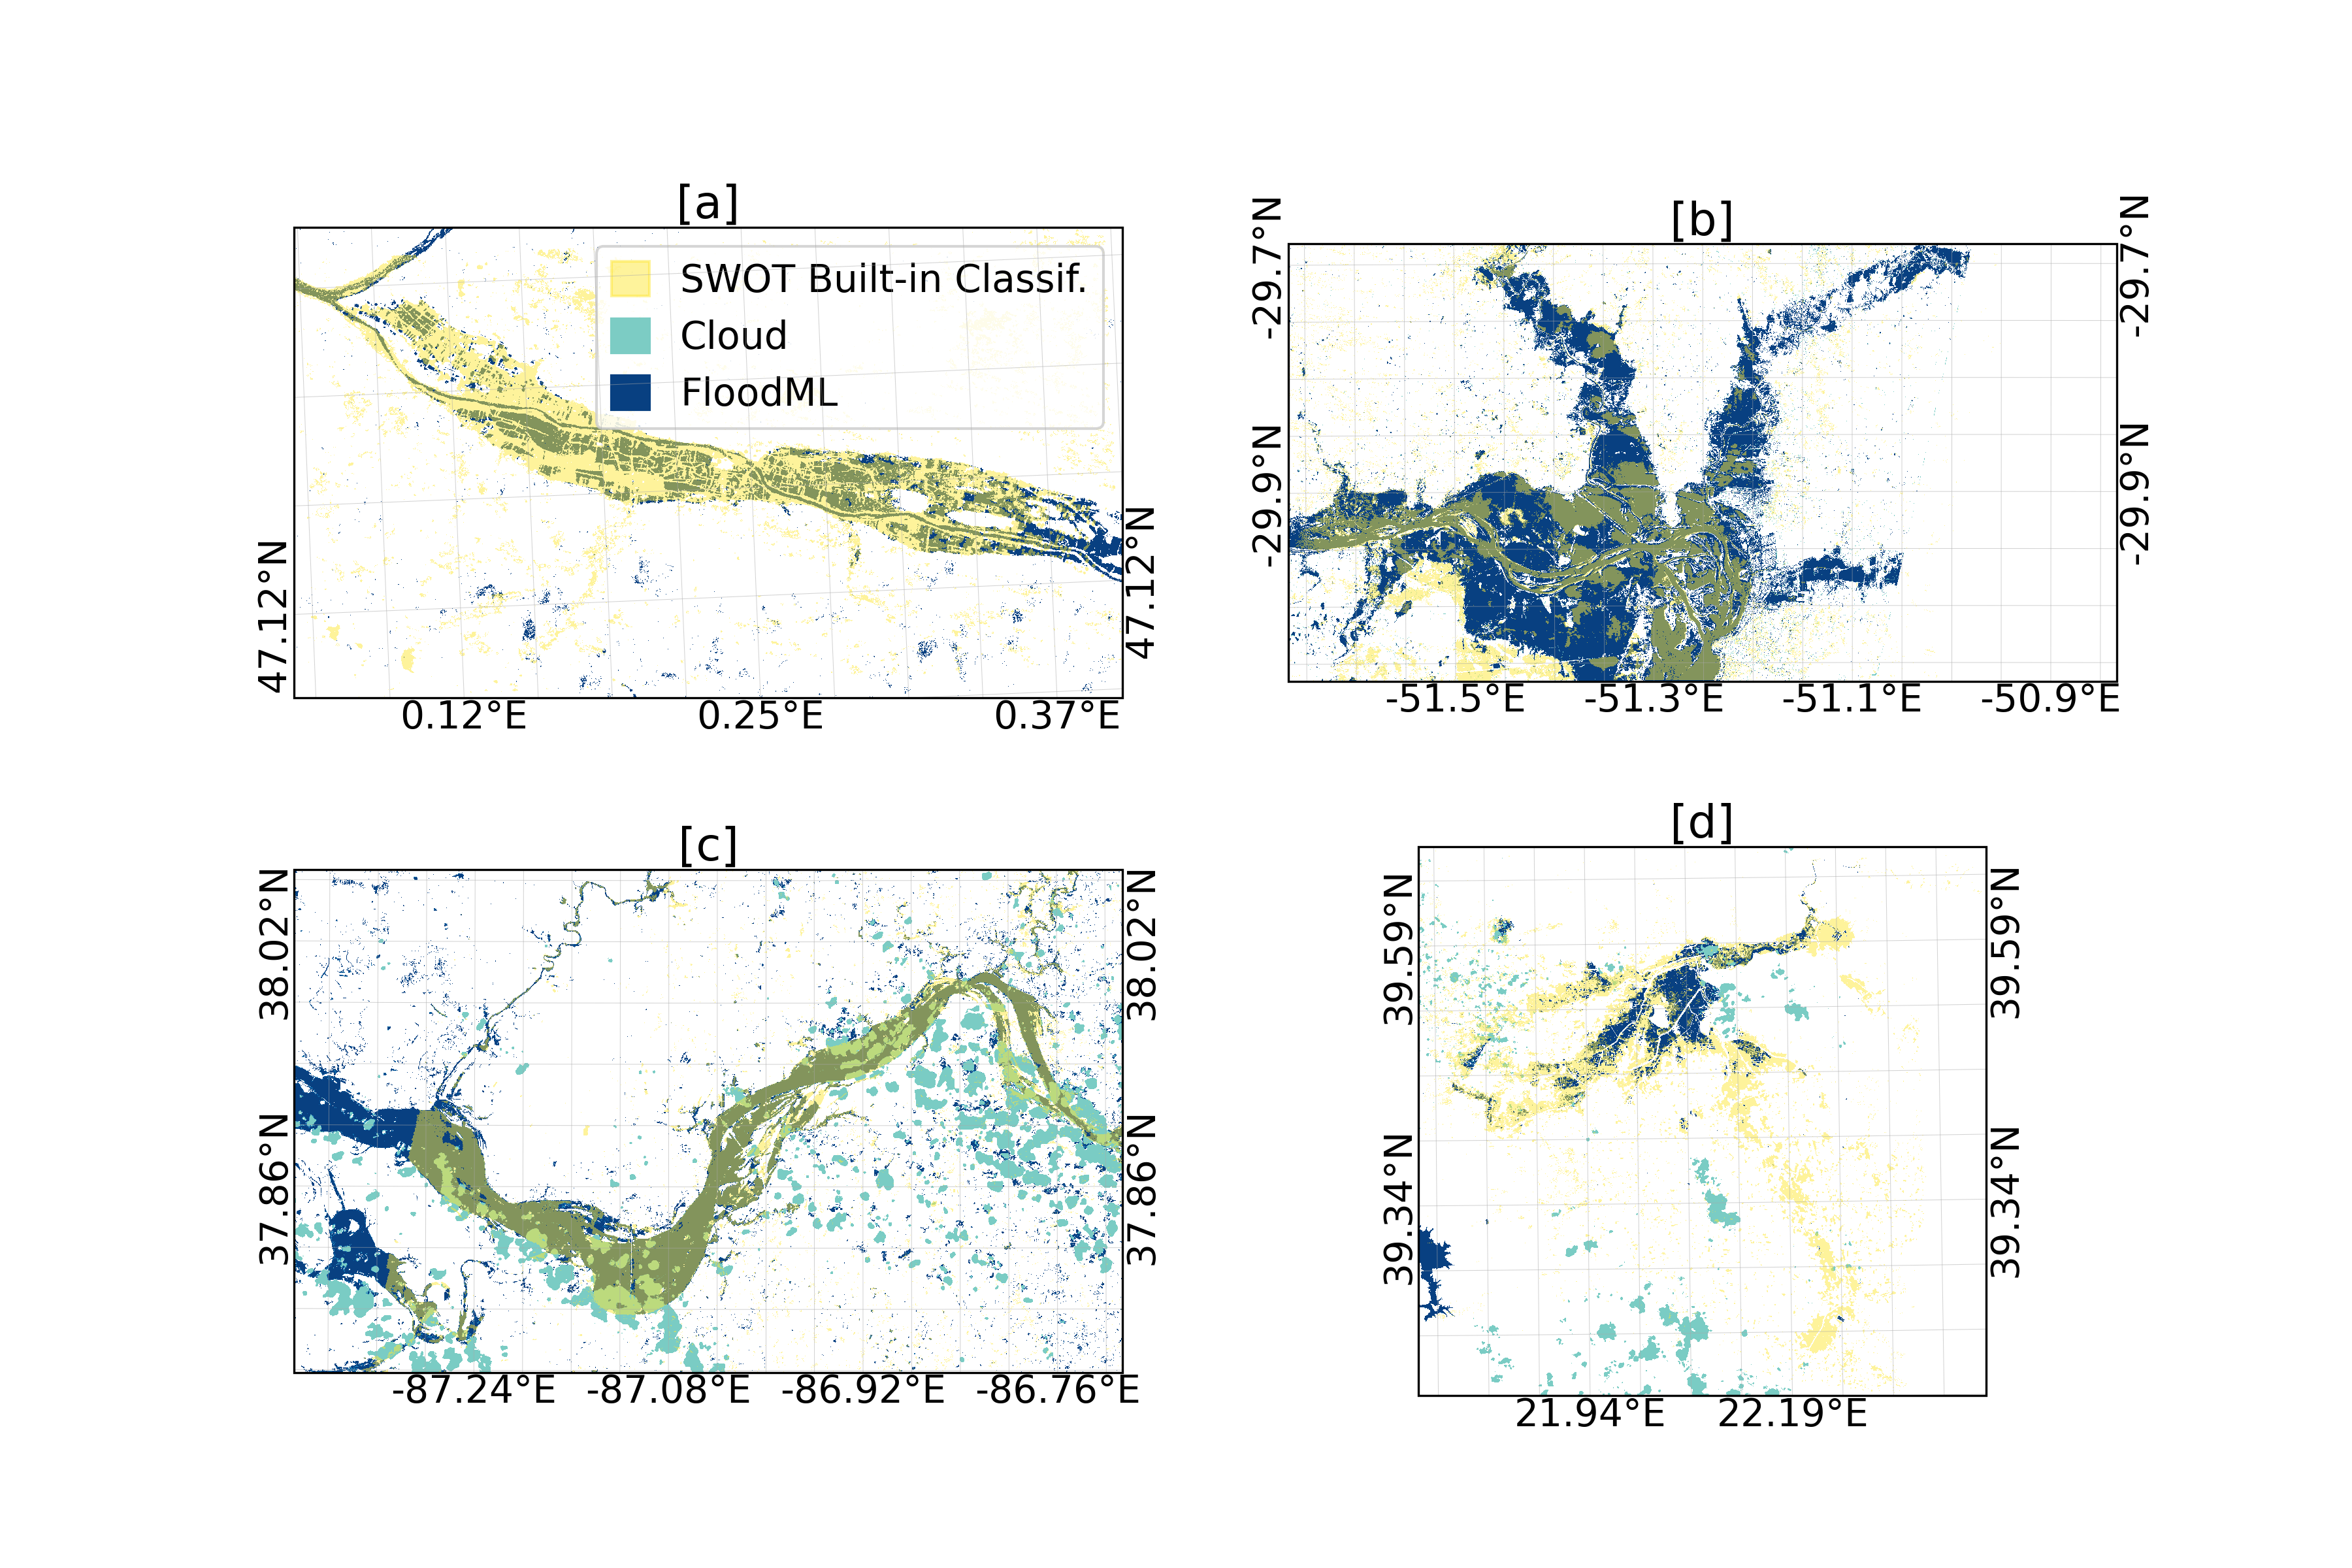

In [ ]:
dpi = 2244/12
fig, ax = plt.subplots(2, 2, figsize=(12, 8), dpi=300,
                        subplot_kw={'projection': (cartopy.crs.PlateCarree())})

ax[0, 0].remove()
ax[0, 1].remove()
ax[1, 0].remove()
ax[1, 1].remove()

path_aux_Ohio = Ohio_project.AUX_PATH.joinpath("FM_20250220T163229_B02filter_nrow3646_ncol6003.tif")
path_aux_Chinon = Chinon_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif")
path_aux_PortAlegre = PortoAlegre_project.AUX_PATH.joinpath("FLoodML_20240506T133149_cut_32722_nrow4248_ncol8052.tif")
path_aux_EMSR692 = EMSR692_project.AUX_PATH.joinpath("FM_34SEJ_20230915_CUT_nrow5720_ncol5917.tif")
title_aux_Chinon =     "[a]" #   "FloodML mask from Sentinel-1 image (2024-03-31 17:48)"
title_aux_PortAlegre = "[b]" #   "Sentinel-2A RGB image (2024-05-06 13:13)"
title_aux_Ohio =       "[c]" #   "FloodML mask from Sentinel-1 image (2025-02-22 23:48)"
title_aux_EMSR692 =    "[d]" #   "FloodML mask from Sentinel-2A image (2023-09-15 09:20)"

Chinon_plot.plot_auxiliary_data(
    path_to_raster=path_aux_Chinon,
    title=title_aux_Chinon,
    is_multiband=False,
    is_worldcover=False,
    make_mask = True,
    mask_value = 1,
    cmap = Colormap("GnBu").to_matplotlib(),
    vmin=0,
    vmax=1,
    fig=fig,
    ax=(2,2,1),
    add_cbar=False,
    add_legend=True,
    add_classification_mask=True,
    classification_time_selection='2024-03-31',
    aux_label = 'FloodML'
)

PortoAlegre_plot.plot_auxiliary_data(
    path_to_raster=path_aux_PortAlegre,
    title=title_aux_PortAlegre,
    is_multiband=False, 
    is_worldcover=False,
    make_mask = True,
    mask_value = 1,
    cmap = Colormap("GnBu").to_matplotlib(),
    vmin=0,
    vmax=1,
    fig=fig,
    ax=(2,2,2),
    add_cbar=False,
    add_legend=False,
    add_classification_mask=True,
    classification_time_selection='2024-05-06'
)

Ohio_plot.plot_auxiliary_data(
    path_to_raster=path_aux_Ohio,
    title=title_aux_Ohio,
    is_multiband=False,
    is_worldcover=False,
    make_mask = True,
    mask_value = 1,
    cmap = Colormap("GnBu").to_matplotlib(),
    vmin=0,
    vmax=1,
    fig=fig,
    ax=(2,2,3),
    add_cbar=False,
    add_legend=False,
    add_classification_mask=True,
    classification_time_selection='2025-02-20'
)

_, ax = EMSR692_plot.plot_auxiliary_data(
    path_to_raster=path_aux_EMSR692,
    title=title_aux_EMSR692,
    is_multiband=False,
    is_worldcover=False,
    make_mask = True,
    mask_value = 1,
    cmap = Colormap("GnBu").to_matplotlib(),
    vmin=0,
    vmax=1,
    fig=fig,
    ax=(2,2,4),
    add_cbar=False,
    add_legend=False,
    add_classification_mask=True,
    classification_time_selection='2023-09-15'
)

fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/FloodML_compile.pdf",
    dpi=dpi,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/FloodML_compile.png",
    dpi=dpi,
)
plt.show()

## S2 / S1

In [ ]:
dpi = 2244/12
fig, ax = plt.subplots(2, 2, figsize=(12, 8),  dpi=300,
                        subplot_kw={'projection': (cartopy.crs.PlateCarree())})
ax[0, 0].remove()
ax[0, 1].remove()
ax[1, 0].remove()
ax[1, 1].remove()

path_aux_Ohio = Ohio_project.AUX_PATH.joinpath("B04_B03_B02_cut.tif")
path_aux_Chinon = Chinon_project.AUX_PATH.joinpath("s1a_30TYT_vv_ASC_132_20240331t174856_cut.tif")
path_aux_PortAlegre = PortoAlegre_project.AUX_PATH.joinpath("S2A_merged_32722_20240506T131349.tif")
path_aux_EMSR692 = EMSR692_project.AUX_PATH.joinpath("S2A_20230915_TCI_32634.tif")
title_aux_Chinon =     "[a]" #   "FloodML mask from Sentinel-1 image (2024-03-31 17:48)"
title_aux_PortAlegre = "[b]" #   "Sentinel-2A RGB image (2024-05-06 13:13)"
title_aux_Ohio =       "[c]" #   "FloodML mask from Sentinel-1 image (2025-02-22 23:48)"
title_aux_EMSR692 =    "[d]" #   "FloodML mask from Sentinel-2A image (2023-09-15 09:20)"

Chinon_plot.plot_auxiliary_data(
    path_to_raster=path_aux_Chinon,
    title=title_aux_Chinon,
    is_multiband=False,
    is_worldcover=False,
    vmin=0,
    vmax=0.5,
    fig=fig,
    ax=(2,2,1),
    add_cbar=False
)

PortoAlegre_plot.plot_auxiliary_data(
    path_to_raster=path_aux_PortAlegre,
    title=title_aux_PortAlegre,
    is_multiband=True, 
    is_worldcover=False,
    fig=fig,
    ax=(2,2,2),
    add_cbar=False
)

Ohio_plot.plot_auxiliary_data(
    path_to_raster=path_aux_Ohio,
    title=title_aux_Ohio,
    is_multiband=True,
    is_worldcover=False,
    fig=fig,
    ax=(2,2,3),
    add_cbar=False,
    constraint_range=(1000, 5000)
)

_, ax = EMSR692_plot.plot_auxiliary_data(
    path_to_raster=path_aux_EMSR692,
    title=title_aux_EMSR692,
    is_multiband=True,
    is_worldcover=False,
    fig=fig,
    ax=(2,2,4),
    add_cbar=False
)

fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/S1_S2_compile.pdf",
    dpi=dpi,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/S1_S2_compile.png",
    dpi=dpi,
)
plt.show()

# ESA World Cover

In [ ]:
def plot_polygons(plot_obj,ax):
    polygon_control = plot_obj.swot_collection.controlmask
    polygon_flood = plot_obj.swot_collection.floodmask
    # set crs to WGS84
    # polygon_control = polygon_control.to_crs(4326)
    polygon_flood = polygon_flood.to_crs(4326)
    # plot the polygons
    polygon_control.plot(ax=ax, color="none", edgecolor="black", linewidth=1,)
    polygon_flood.plot(ax=ax, color='blue', alpha=0.5, linewidth=1, zorder=10)

In [ ]:
dpi = 2244/12
import cartopy
from matplotlib import patches as mpatches
from auxiliary.cbar_ESA_WC import defined_ESAWC_cmap
fig = plt.figure(constrained_layout=False, figsize=(12, 8), dpi=300,)
# ax = plt.subplots(2, 2, figsize=(12, 8), dpi=300,
#                         subplot_kw={'projection': (cartopy.crs.PlateCarree())})
gs1 = fig.add_gridspec(2, 3, left=0.02, right=0.98, top=0.98, bottom=0.02, wspace=0.05, hspace=0.05)
# ax1 = fig.add_subplot(gs1[0, 0], projection=cartopy.crs.PlateCarree())
# ax2 = fig.add_subplot(gs1[0, 2], projection=cartopy.crs.PlateCarree())
# ax3 = fig.add_subplot(gs1[1, 0], projection=cartopy.crs.PlateCarree())
# ax4 = fig.add_subplot(gs1[1, 2], projection=cartopy.crs.PlateCarree())
legend_ax = fig.add_subplot(gs1[:, 1])

path_aux_Ohio = Ohio_project.AUX_PATH.joinpath("ESA_WC_Fusion_cut_32616_nrow3646_ncol6003.tif")
path_aux_Chinon = Chinon_project.AUX_PATH.joinpath("ESA_WorldCover_10m_merged_32630_clip_nrow1496_ncol2635.tif")
path_aux_PortAlegre = PortoAlegre_project.AUX_PATH.joinpath("ESA_WorldCover_10m_merged_32722_clip_nrow4248_ncol8052.tif")
path_aux_EMSR692 = EMSR692_project.AUX_PATH.joinpath("ESA_WC_cut_V2_32634_nrow5720_ncol5917.tif")
title_aux_Chinon =     "[a]" #   "FloodML mask from Sentinel-1 image (2024-03-31 17:48)"
title_aux_PortAlegre = "[b]" #   "Sentinel-2A RGB image (2024-05-06 13:13)"
title_aux_Ohio =       "[c]" #   "FloodML mask from Sentinel-1 image (2025-02-22 23:48)"
title_aux_EMSR692 =    "[d]" #   "FloodML mask from Sentine-2A image (2023-09-15 09:20)"

Chinon_plot.plot_auxiliary_data(
    path_to_raster=path_aux_Chinon,
    title=title_aux_Chinon,
    is_multiband=False,
    is_worldcover=True,
    fig=fig,
    ax=(2,3,1),
    add_cbar=False
)

PortoAlegre_plot.plot_auxiliary_data(
    path_to_raster=path_aux_PortAlegre,
    title=title_aux_PortAlegre,
    is_multiband=False, 
    is_worldcover=True,
    fig=fig,
    ax=(2,3,3),
    add_cbar=False
)

Ohio_plot.plot_auxiliary_data(
    path_to_raster=path_aux_Ohio,
    title=title_aux_Ohio,
    is_multiband=False,
    is_worldcover=True,
    fig=fig,
    ax=(2,3,4),
    add_cbar=False
)

_, ax = EMSR692_plot.plot_auxiliary_data(
    path_to_raster=path_aux_EMSR692,
    title=title_aux_EMSR692,
    is_multiband=False,
    is_worldcover=True,
    fig=fig,
    ax=(2,3,6),
    add_cbar=False
)

ll = []
cmap_ESAWC, normalizer_ESAWC, boundaries_ESAWC, ticks_ESAWC, tick_labels_ESAWC, values_ESAWC = defined_ESAWC_cmap()
for value, label in zip(values_ESAWC, tick_labels_ESAWC):
    ll.append(mpatches.Patch(color=cmap_ESAWC(value), label=label))
legend_ax.legend(handles=ll, loc="center", handlelength=1, handleheight=1, fontsize=12)
legend_ax.axis('off')

# plot_polygons(Chinon_plot, ax[0])
# plot_polygons(PortoAlegre_plot, ax[1])
# plot_polygons(Ohio_plot, ax[2])
# plot_polygons(EMSR692_plot, ax[3])

# handles = [
#     Line2D([0], [0], linestyle='none', mfc='blue', mec='blue', alpha=0.5, marker='s', label='flood mask'),
#     Line2D([0], [0], linestyle='-', color='black', mfc='none', mec='none', marker='s', label='control mask'),
# ]
# ax[0].legend(handles=handles, loc="upper right", fontsize=14)

fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/ESA_WC_compile.pdf",
    dpi=dpi,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/ESA_WC_compile.png",
    dpi=dpi,
)
plt.show(fig)

# SWOT Classification

In [ ]:
dpi = 2244/12
import cartopy
from auxiliary.cbar_SWOT import defined_SWOT_cmap
fig = plt.figure(constrained_layout=False, figsize=(12, 8), dpi=300,)
# ax = plt.subplots(2, 2, figsize=(12, 8), dpi=300,
#                         subplot_kw={'projection': (cartopy.crs.PlateCarree())})
gs1 = fig.add_gridspec(2, 3, left=0.02, right=0.98, top=0.98, bottom=0.02, wspace=0.05, hspace=0.05)
# ax1 = fig.add_subplot(gs1[0, 0], projection=cartopy.crs.PlateCarree())
# ax2 = fig.add_subplot(gs1[0, 2], projection=cartopy.crs.PlateCarree())
# ax3 = fig.add_subplot(gs1[1, 0], projection=cartopy.crs.PlateCarree())
# ax4 = fig.add_subplot(gs1[1, 2], projection=cartopy.crs.PlateCarree())
legend_ax = fig.add_subplot(gs1[:, 1])

title_aux_Chinon =     "[a]" #   "FloodML mask from Sentinel-1 image (2024-03-31 17:48)"
title_aux_PortAlegre = "[b]" #   "Sentinel-2A RGB image (2024-05-06 13:13)"
title_aux_Ohio =       "[c]" #   "FloodML mask from Sentinel-1 image (2025-02-22 23:48)"
title_aux_EMSR692 =    "[d]" #   "FloodML mask from Sentine-2A image (2023-09-15 09:20)"

Chinon_plot.plot_classification(
    data_area="global",
    time_selection='2024-03-31',
    title=title_aux_Chinon,
    show_fig=False,
    save_fig=False,
    add_legend=False,
    fig=fig,
    ax=(2,3,1),
)

PortoAlegre_plot.plot_classification(
    data_area="global",
    time_selection='2024-05-06',
    title=title_aux_PortAlegre,
    show_fig=False,
    save_fig=False,
    add_legend=False,
    fig=fig,
    ax=(2,3,3),
)

Ohio_plot.plot_classification(
    data_area="global",
    time_selection='2025-02-20',
    title=title_aux_Ohio,
    show_fig=False,
    save_fig=False,
    add_legend=False,
    fig=fig,
    ax=(2,3,4),
)

_, ax = EMSR692_plot.plot_classification(
    data_area="global",
    time_selection='2023-09-15',
    title=title_aux_EMSR692,
    show_fig=False,
    save_fig=False,
    add_legend=False,
    fig=fig,
    ax=(2,3,6),
)

ll = []
cmap_SWOT, _, _, _, tick_labels_SWOT, values_SWOT = defined_SWOT_cmap()
for value, label in zip(values_SWOT, tick_labels_SWOT):
    ll.append(mpatches.Patch(color=cmap_SWOT(value), label=label))
legend_ax.legend(handles=ll, loc="center", handlelength=1, handleheight=1, fontsize=12)
legend_ax.axis('off')

fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/SWOT_classification_compile.pdf",
    dpi=dpi,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/SWOT_classification_compile.png",
    dpi=dpi,
)
plt.show()

# Mean histogram

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))

title_aux_Chinon =     "[a]" #   "FloodML mask from Sentinel-1 image (2024-03-31 17:48)"
title_aux_PortAlegre = "[b]" #   "Sentinel-2A RGB image (2024-05-06 13:13)"
title_aux_Ohio =       "[c]" #   "FloodML mask from Sentinel-1 image (2025-02-22 23:48)"
title_aux_EMSR692 =    "[d]" #   "FloodML mask from Sentine-2A image (2023-09-15 09:20)"

Chinon_plot.plot_mean_hist_computation(
    variable="gamma_tot",
    title=title_aux_Chinon,
    fig=fig,
    ax=ax[0,0],
)
PortoAlegre_plot.plot_mean_hist_computation(
    variable="gamma_tot",
    title=title_aux_PortAlegre,
    fig=fig,
    ax=ax[0,1],
)
Ohio_plot.plot_mean_hist_computation(
    variable="gamma_tot",
    title=title_aux_Ohio,
    fig=fig,
    ax=ax[1,0],
)
_, ax = EMSR692_plot.plot_mean_hist_computation(
    variable="gamma_tot",
    title=title_aux_EMSR692,
    fig=fig,
    ax=ax[1,1],
)
fig.tight_layout()
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/mean_computation_gamma_tot_compile.pdf",
    dpi=300,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/mean_computation_gamma_tot_compile.png",
    dpi=300,
)
plt.show()

# Histogram in world cover

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(15,10))

ax[0,0].set_ylabel("Chinon, France", fontsize=12, fontweight='bold')
ax[1,0].set_ylabel("Porto Alegre\nRio Grande do Sul\nEMSN 192", fontsize=12, fontweight='bold')
ax[2,0].set_ylabel("Owensboro, USA\nOhio River", fontsize=12, fontweight='bold')
ax[3,0].set_ylabel("Farkadona, Greece\nEMSR 692", fontsize=12, fontweight='bold')

y_text = 0.95

####################
# Chinon
Chinon_plot.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection="open",
    time_selection='2024-03-31',
    use_seaborn=False,
    add_ylabel=False,
    add_xlabel=False,
    title="[a]",
    fig=fig,
    ax=ax[0,0],
    y_text=y_text
)
Chinon_plot.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection="forest",
    time_selection='2024-03-31',
    use_seaborn=False,
    title="[b]",
    add_ylabel=False,
    add_xlabel=False,
    fig=fig,
    ax=ax[0,1],
    y_text=y_text
)
ax[0,2].remove() # no urban in Chinon

####################
# Porto Alegre
PortoAlegre_plot.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection="open",
    time_selection='2024-05-06',
    use_seaborn=False,
    add_ylabel=False,
    add_xlabel=False,
    title="[c]",
    fig=fig,
    ax=ax[1,0],
    y_text=y_text
)
PortoAlegre_plot.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection="forest",
    time_selection='2024-05-06',
    use_seaborn=False,
    title="[d]",
    add_ylabel=False,
    add_xlabel=False,
    fig=fig,
    ax=ax[1,1],
    y_text=y_text
)
PortoAlegre_plot.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection="urban",
    time_selection='2024-05-06',
    use_seaborn=False,
    title="[e]",
    add_ylabel=False,
    add_xlabel=False,
    fig=fig,
    ax=ax[1,2],
    y_text=y_text,
    ha="right",
    va="top",
    ha_mean="left",
)
####################
# Ohio
Ohio_plot.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection="open",
    time_selection='2025-02-20',
    use_seaborn=False,
    add_ylabel=False,
    add_xlabel=False,
    title="[f]",
    fig=fig,
    ax=ax[2,0],
    y_text=y_text
)
Ohio_plot.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection="forest",
    time_selection='2025-02-20',
    title="[g]",
    use_seaborn=False,
    add_ylabel=False,
    add_xlabel=False,
    fig=fig,
    ax=ax[2,1],
    y_text=y_text
)
ax[2,2].remove() # no urban in Ohio
####################
# Greece
EMSR692_plot.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection="open",
    time_selection='2023-09-15',
    use_seaborn=False,
    add_ylabel=False,
    add_xlabel=True,
    title="[h]",
    fig=fig,
    ax=ax[3,0],
    y_text=y_text
)
EMSR692_plot.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection="forest",
    time_selection='2023-09-15',
    title="[i]",
    use_seaborn=False,
    add_ylabel=False,
    add_xlabel=True,
    fig=fig,
    ax=ax[3,1],
    y_text=y_text
)
EMSR692_plot.plot_histogram(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    world_cover_selection="urban",
    time_selection='2023-09-15',
    title="[j]",
    use_seaborn=False,
    add_ylabel=False,
    add_xlabel=True,
    fig=fig,
    ax=ax[3,2],
    y_text=y_text
)

# Save figure
fig.tight_layout()
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/histo_gamma_tot_compile.pdf",
    dpi=300,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/histo_gamma_tot_compile.png",
    dpi=300,
)
plt.show()

# Water Masks

In [ ]:
from matplotlib import patches as mpatches
import cartopy
fig, ax = plt.subplots(2, 2, figsize=(25,20))
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, hspace=0.1, wspace=0.1)

ax[0,0].remove()
ax[0,1].remove()
ax[1,0].remove()
ax[1,1].remove()


####################
# Chinon
Chinon_plot.plot_map_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    time_selection="2024-03-31",
    title="[a]",
    comparing_raster_Path=Chinon_plot.project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1493_ncol2633.tif"),
    thresholds={"urban":-0, "forest":0.75, "open":0.75},
    add_classif_score=True,
    add_uncertainty=True,
    threshold_SNR=0.5,
    add_bkg=False,
    add_legend=False,
    disk_size=3,
    ax=(2,2,1),
    fig=fig
    )

####################
# Porto Alegre
PortoAlegre_plot.plot_map_mask(
    variable="gamma_tot", 
    data_area="global", #global or flood or control
    # data_type="diff", #diff or swot or mean (not working well for mean)
    data_type="swot", #swot
    time_selection="2024-05-06",
    title="[b]",
    # thresholds={"urban":-0.1, "forest":0.1, "open":0.1}, #diff
    # thresholds={"urban":-0., "forest":0.7, "open":0.8}, #swot
    thresholds={"urban":-0.1, "forest":0.65, "open":0.8}, # swot with urban diff
    urban_diff=True,
    add_classif_score=True,
    add_uncertainty=True,
    threshold_SNR=0.5,
    # threshold_gamma=-0.15, #diff
    threshold_gamma=0.5, #swot
    add_bkg=False,
    add_legend=False,
    disk_size=3,
    ax=(2,2,2),
    fig=fig
    )

####################
# Ohio
Ohio_plot.plot_map_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    time_selection="2025-02-20",
    comparing_raster_Path=Ohio_plot.project.AUX_PATH.joinpath("FM_20250222T000000_S1_POST_fusion_cut_32616_nrow3646_ncol6003.tif"),
    thresholds={"urban":-0, "forest":0.7, "open":0.85},
    title="[c]",
    add_classif_score=True,
    add_uncertainty=True,
    threshold_SNR=0.5,
    threshold_gamma=0.2,
    add_bkg=False,
    add_legend=False,
    disk_size=3,
    ax=(2,2,3),
    fig=fig
    )

####################
# Greece
fig, ax = EMSR692_plot.plot_map_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    time_selection="2023-09-15",
    title="[d]",
    comparing_raster_Path=EMSR692_plot.project.AUX_PATH.joinpath("FM_34SEJ_20230915_CUT_nrow5720_ncol5917.tif"),
    thresholds={"urban":0.9, "forest":0.85, "open":0.85},
    add_classif_score=True,
    add_uncertainty=True,
    threshold_SNR=0.5,
    add_bkg=False,
    add_legend=False,
    disk_size=3,
    ax=(2,2,4),
    fig=fig
    )

# Add arrow for Nadir direction
# Chinon : East > West
# Porto Alegre : West > East
# Ohio : East > West
# Greece : West > East
add_arrow_range(ax[0], "Chinon")
add_arrow_range(ax[1], "PortoAlegre")
add_arrow_range(ax[2], "Ohio")
add_arrow_range(ax[3], "Greece")

# plot in porto alegre [-51.2, -51.1, -29.8, -29.7] and [-51.25, -51.1, -30, -29.85] rectangle
ax[1].add_patch(
    mpatches.Rectangle(
        xy=(-51.2, -29.8),  # lower left corner
        width=0.1,  # width of rectangle
        height=0.1,  # height of rectangle
        linewidth=2,
        color="black",
        linestyle='--',
        edgecolor="black",
        fill=False,
        transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[1]),
    )
)
print(ax[-1], ax[1])
ax[1].add_patch(
    mpatches.Rectangle(
        xy=(-51.25, -30),  # lower left corner
        width=0.15,  # width of rectangle
        height=0.15,  # height of rectangle
        linewidth=2,
        color="black",
        linestyle='--',
        edgecolor="black",
        fill=False,
        transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[1]),
    )
)

# plot in greece [21.94, 22.15, 39.47, 39.59] rectangle
ax[-1].add_patch(
    mpatches.Rectangle(
        xy=(21.94, 39.47),  # lower left corner
        width=0.21,  # width of rectangle
        height=0.12,  # height of rectangle
        linewidth=2,
        color="black",
        linestyle='--',
        edgecolor="black",
        fill=False,
        transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[-1]),
    )
)

cmap, color_labels = EMSR692_plot.get_floodmask_colormap(True)
l1 = mpatches.Patch(color='red', label=color_labels[1])
l2 = mpatches.Patch(color='forestgreen', label=color_labels[2])
l3 = mpatches.Patch(color='cornflowerblue', label=color_labels[3])
l11 = mpatches.Patch(color='rosybrown', label=color_labels[11])
l12 = mpatches.Patch(color='yellowgreen', label=color_labels[12])
l13 = mpatches.Patch(color='darkcyan', label=color_labels[13])
l21 = mpatches.Patch(color='darkred', label=color_labels[21])
l22 = mpatches.Patch(color='darkgreen', label=color_labels[22])
l23 = mpatches.Patch(color='darkblue', label=color_labels[23])
ax[-2].legend(handles=[l1, l2, l3, l11, l12, l13, l21, l22, l23],loc="lower left", fontsize=18, ncols=3, bbox_to_anchor=(0.,-0.25), handlelength=1, handleheight=1)

# Save figure
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/mask_maps_compile.pdf",
    dpi=300,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/mask_maps_compile.png",
    dpi=300,
)
plt.show()

In [ ]:
from matplotlib import patches as mpatches
fig, ax = plt.subplots(1, 3, figsize=(30,10))
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, hspace=0.1, wspace=0.1)

ax[0].remove()
ax[1].remove()
ax[2].remove()

#######################
# ZOOM mask

#######################
# Porto Alegre - Zoom 1
PortoAlegre_plot.plot_map_mask(
    variable="gamma_tot", 
    data_area="global", #global or flood or control
    # data_type="diff", #diff or swot or mean (not working well for mean)
    data_type="swot", #swot
    time_selection="2024-05-06",
    title="[a]",
    # thresholds={"urban":-0.1, "forest":0.1, "open":0.1}, #diff
    # thresholds={"urban":-0., "forest":0.7, "open":0.8}, #swot
    thresholds={"urban":-0.1, "forest":0.65, "open":0.8}, # swot with urban diff
    urban_diff=True,
    add_classif_score=True,
    add_uncertainty=True,
    threshold_SNR=0.5,
    # threshold_gamma=-0.15, #diff
    threshold_gamma=0.5, #swot
    add_bkg=False,
    add_legend=False,
    disk_size=3,
    ax=(1,3,1),
    fig=fig,
    extents=[-51.2, -51.1, -29.8, -29.7] # North Porto Alegre
    )

# Porto Alegre - Zoom 2
PortoAlegre_plot.plot_map_mask(
    variable="gamma_tot", 
    data_area="global", #global or flood or control
    # data_type="diff", #diff or swot or mean (not working well for mean)
    data_type="swot", #swot
    time_selection="2024-05-06",
    title="[b]",
    # thresholds={"urban":-0.1, "forest":0.1, "open":0.1}, #diff
    # thresholds={"urban":-0., "forest":0.7, "open":0.8}, #swot
    thresholds={"urban":-0.1, "forest":0.65, "open":0.8}, # swot with urban diff
    urban_diff=True,
    add_classif_score=True,
    add_uncertainty=True,
    threshold_SNR=0.5,
    # threshold_gamma=-0.15, #diff
    threshold_gamma=0.5, #swot
    add_bkg=False,
    add_legend=False,
    disk_size=3,
    ax=(1,3,2),
    fig=fig,
    extents=[-51.25, -51.1, -30, -29.85] # South Porto Alegre
    )

####################
# Greece - Zoom 1
fig, ax = EMSR692_plot.plot_map_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    time_selection="2023-09-15",
    title="[c]",
    comparing_raster_Path=EMSR692_plot.project.AUX_PATH.joinpath("FM_34SEJ_20230915_CUT_nrow5720_ncol5917.tif"),
    thresholds={"urban":0.9, "forest":0.85, "open":0.85},
    add_classif_score=True,
    add_uncertainty=True,
    threshold_SNR=0.5,
    add_bkg=False,
    add_legend=False,
    disk_size=3,
    ax=(1,3,3),
    fig=fig,
    extents=[21.94, 22.15, 39.47, 39.59] # Zoom on Metamorfosis village and neighbourhood
    )

cmap, color_labels = EMSR692_plot.get_floodmask_colormap(True)
l1 = mpatches.Patch(color=cmap(1), label=color_labels[1])
l2 = mpatches.Patch(color=cmap(2), label=color_labels[2])
l3 = mpatches.Patch(color=cmap(3), label=color_labels[3])
l11 = mpatches.Patch(color=cmap(11), label=color_labels[11])
l12 = mpatches.Patch(color=cmap(12), label=color_labels[12])
l13 = mpatches.Patch(color=cmap(13), label=color_labels[13])
l21 = mpatches.Patch(color=cmap(21), label=color_labels[21])
l22 = mpatches.Patch(color=cmap(22), label=color_labels[22])
l23 = mpatches.Patch(color=cmap(23), label=color_labels[23])
ax[-1].legend(handles=[l1, l2, l3, l11, l12, l13, l21, l22, l23],loc="lower left", fontsize=18, ncols=3, bbox_to_anchor=(-0.1,-0.25), handlelength=1, handleheight=1)

# Save figure
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/mask_maps_compile_zoom.pdf",
    dpi=300,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/mask_maps_compile_zoom.png",
    dpi=300,
)
plt.show()

# Plot map of gamma_tot

## Mean data

In [ ]:
fig, ax = plt.subplots(2 , 2, figsize=(25,20))

ax[0,0].remove()
ax[0,1].remove()
ax[1,0].remove()
ax[1,1].remove()

####################
# Chinon
Chinon_plot.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2024-03-31",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False,
    title="[a]",
    ax=(2,2,1),
    fig=fig
    )

####################
# Porto Alegre
PortoAlegre_plot.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2024-05-06",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False,
    title="[b]",
    ax=(2,2,2),
    fig=fig
)

####################
# Ohio
Ohio_plot.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2025-02-20",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False,
    title="[c]",
    ax=(2,2,3),
    fig=fig
)

####################
# Greece
fig, ax = EMSR692_plot.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2023-09-15",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False,
    title="[d]",
    ax=(2,2,4),
    fig=fig
)


# Add arrow for Nadir direction
# Chinon : East > West
# Porto Alegre : West > East
# Ohio : East > West
# Greece : West > East
add_arrow_range(ax[0],  "Chinon")
add_arrow_range(ax[4],  "PortoAlegre")
add_arrow_range(ax[8],  "Ohio")
add_arrow_range(ax[12], "Greece")

plt.show()

# Save figure
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/maps_mean_gamma_tot_compile.pdf",
    dpi=300,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/maps_mean_gamma_tot_compile.png",
    dpi=300,
)

In [ ]:
fig, ax = plt.subplots(2 , 2, figsize=(15,15))

ax[0,0].remove()
ax[0,1].remove()
ax[1,0].remove()
ax[1,1].remove()

####################
# Chinon
Chinon_plot.plot_map(
    variable="coherent_power",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2024-03-31",
    cmap="magma",
    vmin=45,
    vmax=85,
    add_bkg=False,
    title="[a]",
    ax=(2,2,1),
    fig=fig
    )

####################
# Porto Alegre
PortoAlegre_plot.plot_map(
    variable="coherent_power",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2024-05-06",
    cmap="magma",
    vmin=45,
    vmax=85,
    add_bkg=False,
    title="[b]",
    ax=(2,2,2),
    fig=fig
)

####################
# Ohio
Ohio_plot.plot_map(
    variable="coherent_power",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2025-02-20",
    cmap="magma",
    vmin=45,
    vmax=85,
    add_bkg=False,
    title="[c]",
    ax=(2,2,3),
    fig=fig
)

####################
# Greece
fig, ax = EMSR692_plot.plot_map(
    variable="coherent_power",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2023-09-15",
    cmap="magma",
    vmin=45,
    vmax=85,
    add_bkg=False,
    title="[d]",
    ax=(2,2,4),
    fig=fig
)


# Add arrow for Nadir direction
# Chinon : East > West
# Porto Alegre : West > East
# Ohio : East > West
# Greece : West > East
add_arrow_range(ax[0],  "Chinon")
add_arrow_range(ax[4],  "PortoAlegre")
add_arrow_range(ax[8],  "Ohio")
add_arrow_range(ax[12], "Greece")

plt.show()

# Save figure
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/maps_mean_coherent_power_compile.pdf",
    dpi=300,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/maps_mean_coherent_power_compile.png",
    dpi=300,
)

In [ ]:
fig, ax = plt.subplots(2 , 2, figsize=(15,15))

ax[0,0].remove()
ax[0,1].remove()
ax[1,0].remove()
ax[1,1].remove()

####################
# Chinon
Chinon_plot.plot_map(
    variable="sig0",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2024-03-31",
    cmap="viridis",
    vmin=-20,
    vmax=40,
    add_bkg=False,
    title="[a]",
    ax=(2,2,1),
    fig=fig
    )

####################
# Porto Alegre
PortoAlegre_plot.plot_map(
    variable="sig0",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2024-05-06",
    cmap="viridis",
    vmin=-20,
    vmax=40,
    add_bkg=False,
    title="[b]",
    ax=(2,2,2),
    fig=fig
)

####################
# Ohio
Ohio_plot.plot_map(
    variable="sig0",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2025-02-20",
    cmap="viridis",
    vmin=-20,
    vmax=40,
    add_bkg=False,
    title="[c]",
    ax=(2,2,3),
    fig=fig
)

####################
# Greece
fig, ax = EMSR692_plot.plot_map(
    variable="sig0",
    data_area="global",
    data_type="mean",
    world_cover_selection=None,
    time_selection="2023-09-15",
    cmap="viridis",
    vmin=-20,
    vmax=40,
    add_bkg=False,
    title="[d]",
    ax=(2,2,4),
    fig=fig
)


# Add arrow for Nadir direction
# Chinon : East > West
# Porto Alegre : West > East
# Ohio : East > West
# Greece : West > East
add_arrow_range(ax[0],  "Chinon")
add_arrow_range(ax[4],  "PortoAlegre")
add_arrow_range(ax[8],  "Ohio")
add_arrow_range(ax[12], "Greece")

plt.show()

# Save figure
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/maps_mean_sig0_compile.pdf",
    dpi=300,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/maps_mean_sig0_compile.png",
    dpi=300,
)

## SWOT data

In [ ]:
fig, ax = plt.subplots(2 , 2, figsize=(25,20))

ax[0,0].remove()
ax[0,1].remove()
ax[1,0].remove()
ax[1,1].remove()

####################
# Chinon
Chinon_plot.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection=None,
    time_selection="2024-03-31",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False,
    title="[a]",
    ax=(2,2,1),
    fig=fig
    )

####################
# Porto Alegre
PortoAlegre_plot.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection=None,
    time_selection="2024-05-06",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False,
    title="[b]",
    ax=(2,2,2),
    fig=fig
)

####################
# Ohio
Ohio_plot.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection=None,
    time_selection="2025-02-20",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False,
    title="[c]",
    ax=(2,2,3),
    fig=fig
)

####################
# Greece
fig, ax = EMSR692_plot.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection=None,
    time_selection="2023-09-15",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False,
    title="[d]",
    ax=(2,2,4),
    fig=fig
)


# Add arrow for Nadir direction
# Chinon : East > West
# Porto Alegre : West > East
# Ohio : East > West
# Greece : West > East
add_arrow_range(ax[0],  "Chinon")
add_arrow_range(ax[4],  "PortoAlegre")
add_arrow_range(ax[8],  "Ohio")
add_arrow_range(ax[12], "Greece")

plt.show()

# Save figure
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/maps_gamma_tot_compile.pdf",
    dpi=300,
)
fig.savefig(
    "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/maps_gamma_tot_compile.png",
    dpi=300,
)

# Compare SWOT mask and FM

In [ ]:
from matplotlib import patches as mpatches
from matplotlib import patheffects

print("Creating flood masks for each variable")

for variable in ["sig0", "coherent_power", "gamma_tot"]:
    if variable == "sig0":
        Ohio_thresholds={"urban":-0, "forest":5.5, "open":9.5}
        Ohio_threshold_gamma = 0.5 
        PA_thresholds={"urban":-0, "forest":5, "open":10}
        PA_urban_diff=False
        PA_threshold_gamma=0.1 #swot
        Greece_thresholds={"urban":8, "forest":7, "open":9}
        Greece_urban_diff=True
        Chinon_thresholds={"urban":-0, "forest":10, "open":10}
        
    elif variable == "coherent_power":
        Ohio_thresholds={"urban":-0, "forest":62.5, "open":65}
        Ohio_threshold_gamma = 0.5
        PA_thresholds={"urban":-0, "forest":62, "open":70}
        PA_urban_diff=False
        PA_threshold_gamma=0.1 #swot
        Greece_thresholds={"urban":70, "forest":65, "open":65}
        Greece_urban_diff=False
        Chinon_thresholds={"urban":-0, "forest":64, "open":64}
        
    elif variable == "gamma_tot":
        Ohio_thresholds={"urban":-0, "forest":0.7, "open":0.85}
        Ohio_threshold_gamma=0.2, #swot
        PA_thresholds={"urban":-0.1, "forest":0.65, "open":0.8} # swot with urban diff
        PA_urban_diff=True
        PA_threshold_gamma=0.5 #swot
        Greece_thresholds={"urban":0.9, "forest":0.85, "open":0.85}
        Greece_urban_diff=False
        Chinon_thresholds={"urban":-0, "forest":0.75, "open":0.75}
        
    ###################
    # Chinon
    Chinon_plot.swot_collection.create_flood_mask(
        variable=variable,
        data_area="global",
        data_type="swot",
        thresholds=Chinon_thresholds,
        time_selection="2024-03-31",
        add_uncertainty=True,
        )

    ####################
    # Porto Alegre
    PortoAlegre_plot.swot_collection.create_flood_mask(
        variable=variable,
        data_area="global",
        data_type="swot",
        thresholds=PA_thresholds,
        time_selection="2024-05-06",
        urban_diff=PA_urban_diff,
        threshold_gamma=PA_threshold_gamma,
        add_uncertainty=True,
        )

    ####################
    # Ohio
    Ohio_plot.swot_collection.create_flood_mask(
        variable=variable,
        data_area="global",
        data_type="swot",
        thresholds=Ohio_thresholds,
        time_selection="2025-02-20",
        add_uncertainty=True,
        threshold_gamma=Ohio_threshold_gamma,
        )

    
    ####################
    # Greece
    EMSR692_plot.swot_collection.create_flood_mask(
        variable=variable,
        data_area="global",
        data_type="swot",
        thresholds=Greece_thresholds,
        time_selection="2023-09-15",
        add_uncertainty=True,
        urban_diff=Greece_urban_diff,
        )
    
    print("Plotting water mask", flush=True)
    start = time()
    fig, ax = plt.subplots(2, 2, figsize=(25,20))
    fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, hspace=0.1, wspace=0.1)

    ax[0,0].remove()
    ax[0,1].remove()
    ax[1,0].remove()
    ax[1,1].remove()
    
    ####################
    # Chinon
    Chinon_plot.plot_map_compare_masks(
        variable=variable,
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        title="[a]",
        comparing_raster_Path=Chinon_plot.project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
        add_bkg=False,
        add_legend=False,
        ax=(2,2,1),
        fig=fig
        )

    ####################
    # Porto Alegre
    PortoAlegre_plot.plot_map_compare_masks(
        variable=variable,
        data_area="global", #global or flood or control
        data_type="swot", #swot
        time_selection="2024-05-06",
        title="[b]",
        comparing_raster_Path=PortoAlegre_plot.project.AUX_PATH.joinpath("FLoodML_20240506T133149_cut_32722_nrow4248_ncol8052.tif"),
        add_bkg=False,
        add_legend=False,
        ax=(2,2,2),
        fig=fig
        )

    ####################
    # Ohio
    Ohio_plot.plot_map_compare_masks(
        variable=variable,
        data_area="global",
        data_type="swot",
        time_selection="2025-02-20",
        comparing_raster_Path=Ohio_plot.project.AUX_PATH.joinpath("FM_20250222T000000_S1_POST_fusion_cut_32616_nrow3646_ncol6003.tif"),
        title="[c]",
        add_bkg=False,
        add_legend=False,
        ax=(2,2,3),
        fig=fig
        )

    ####################
    # Greece
    fig, ax = EMSR692_plot.plot_map_compare_masks(
        variable=variable,
        data_area="global",
        data_type="swot",
        time_selection="2023-09-15",
        title="[d]",
        comparing_raster_Path=EMSR692_plot.project.AUX_PATH.joinpath("FM_34SEJ_20230915_CUT_nrow5720_ncol5917.tif"),
        add_bkg=False,
        add_legend=True,
        ax=(2,2,4),
        fig=fig
        )

    ax[0].add_patch(
        mpatches.Rectangle(
            xy=(0.28, 47.1),  # lower left corner
            width=0.03,  # width of rectangle
            height=0.05,  # height of rectangle
            linewidth=2,
            linestyle='--',
            edgecolor="red",
            fill=False,
            transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[0]),
        )
    )
    ax[0].text(
        s="A",
        x=0.284, 
        y=47.1,
        transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[0]),
        fontsize=25,
        color="red",
        ha='center',
        va='center',
        **{'path_effects': [patheffects.withStroke(linewidth=3, foreground='w')]}
    )
        
    # plot in porto alegre [-51.2, -51.1, -29.8, -29.7] and [-51.25, -51.1, -30, -29.85] rectangle
    ax[1].text(
        s="Zoom [a]",
        x=-51.19, 
        y=-29.8,
        fontsize=25,
        color="red",
        transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[1]),
        **{'path_effects': [patheffects.withStroke(linewidth=3, foreground='w')]}
    )
    ax[1].add_patch(
        mpatches.Rectangle(
            xy=(-51.2, -29.8),  # lower left corner
            width=0.1,  # width of rectangle
            height=0.1,  # height of rectangle
            linewidth=2,
            color="red",
            linestyle='--',
            edgecolor="red",
            fill=False,
            transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[1]),
        )
    )
    ax[1].text(
        s="Zoom [b]",
        x=-51.24, 
        y=-30,
        fontsize=25,
        color="red",
        transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[1]),
        **{'path_effects': [patheffects.withStroke(linewidth=3, foreground='w')]}
    )
    
    ax[1].add_patch(
        mpatches.Rectangle(
            xy=(-51.25, -30),  # lower left corner
            width=0.15,  # width of rectangle
            height=0.15,  # height of rectangle
            linewidth=2,
            color="red",
            linestyle='--',
            edgecolor="red",
            fill=False,
            transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[1]),
        )
    )

    # plot in greece [21.94, 22.15, 39.47, 39.59] rectangle
    ax[-1].text(
        s="Zoom [c]",
        x=21.95, 
        y=39.47,
        color="red",
        fontsize=25,
        transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[-1]),
        **{'path_effects': [patheffects.withStroke(linewidth=3, foreground='w')]}
    )
    ax[-1].add_patch(
        mpatches.Rectangle(
            xy=(21.94, 39.47),  # lower left corner
            width=0.21,  # width of rectangle
            height=0.12,  # height of rectangle
            linewidth=2,
            color="red",
            linestyle='--',
            edgecolor="red",
            fill=False,
            transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[-1]),
        )
    )
    # Add arrow for Nadir direction
    # Chinon : East > West
    # Porto Alegre : West > East
    # Ohio : East > West
    # Greece : West > East
    add_arrow_range(ax[0],  "Chinon")
    add_arrow_range(ax[1],  "PortoAlegre")
    add_arrow_range(ax[2],  "Ohio")
    add_arrow_range(ax[3], "Greece")
    
    # Save figure
    fig.savefig(
        f"/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/compared_mask_maps_{variable}_compile.pdf",
        dpi=300,
    )
    fig.savefig(
        f"/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/compared_mask_maps_{variable}_compile.png",
        dpi=300,
    )
    
    plt.close("all")
    print("Elapsed time: ", round(time() - start, 2), "s for merged mask maps", flush=True)
    
    
    print("Plotting zoom maps masks", flush=True)
    fig, ax = plt.subplots(1, 3, figsize=(30,10))
    fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, hspace=0.1, wspace=0.1)

    ax[0].remove()
    ax[1].remove()
    ax[2].remove()

    ####################
    # Porto Alegre - Zoom 1
    PortoAlegre_plot.plot_map_compare_masks(
        variable=variable, 
        data_area="global", #global or flood or control
        data_type="swot", #swot
        time_selection="2024-05-06",
        title="Zoom [a]",
        comparing_raster_Path=PortoAlegre_plot.project.AUX_PATH.joinpath("FLoodML_20240506T133149_cut_32722_nrow4248_ncol8052.tif"),
        add_bkg=False,
        add_legend=False,
        ax=(1,3,1),
        fig=fig,
        extents=[-51.2, -51.1, -29.8, -29.7] # North Porto Alegre
        )

    # Porto Alegre - Zoom 2
    PortoAlegre_plot.plot_map_compare_masks(
        variable=variable, 
        data_area="global", #global or flood or control
        data_type="swot", #swot
        time_selection="2024-05-06",
        title="Zoom [b]",
        comparing_raster_Path=PortoAlegre_plot.project.AUX_PATH.joinpath("FLoodML_20240506T133149_cut_32722_nrow4248_ncol8052.tif"),
        add_bkg=False,
        add_legend=False,
        ax=(1,3,2),
        fig=fig,
        extents=[-51.25, -51.1, -30, -29.85] # South Porto Alegre
        )

    ####################
    # Greece - Zoom 1
    fig, ax = EMSR692_plot.plot_map_compare_masks(
        variable=variable,
        data_area="global",
        data_type="swot",
        time_selection="2023-09-15",
        title="Zoom [c]",
        comparing_raster_Path=EMSR692_plot.project.AUX_PATH.joinpath("FM_34SEJ_20230915_CUT_nrow5720_ncol5917.tif"),
        add_bkg=False,
        add_legend=True,
        ax=(1,3,3),
        fig=fig,
        extents=[21.94, 22.15, 39.47, 39.59] # Zoom on Metamorfosis village and neighbourhood
        )
    
    # Save figure
    fig.savefig(
        f"/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/compared_mask_maps_{variable}_compile_zoom.pdf",
        dpi=300,
    )

    fig.savefig(
        f"/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/Figs/compared_mask_maps_{variable}_compile_zoom.png",
        dpi=300,
    )
    plt.close("all")
    print("Elapsed time: ", round(time() - start, 2), "s for mask maps zoom", flush=True)

    

# Save as tiff

In [ ]:
# variable = "coherent_power"
variable = "sig0"
# variable = "gamma_tot"


if variable == "sig0":
    Ohio_thresholds={"urban":-0, "forest":5.5, "open":9.5}
    Ohio_threshold_gamma = 0.5 
    PA_thresholds={"urban":-0, "forest":5, "open":10}
    PA_urban_diff=False
    PA_threshold_gamma=0.1 #swot
    Greece_thresholds={"urban":8, "forest":7, "open":9}
    Greece_urban_diff=True
    Chinon_thresholds={"urban":-0, "forest":10, "open":10}
    
elif variable == "coherent_power":
    Ohio_thresholds={"urban":-0, "forest":62.5, "open":65}
    Ohio_threshold_gamma = 0.5
    PA_thresholds={"urban":-0, "forest":62, "open":70}
    PA_urban_diff=False
    PA_threshold_gamma=0.1 #swot
    Greece_thresholds={"urban":70, "forest":65, "open":65}
    Greece_urban_diff=False
    Chinon_thresholds={"urban":-0, "forest":64, "open":64}
    
elif variable == "gamma_tot":
    Ohio_thresholds={"urban":-0, "forest":0.7, "open":0.85}
    Ohio_threshold_gamma=0.2, #swot
    PA_thresholds={"urban":-0.1, "forest":0.65, "open":0.8} # swot with urban diff
    PA_urban_diff=True
    PA_threshold_gamma=0.5 #swot
    Greece_thresholds={"urban":0.9, "forest":0.85, "open":0.85}
    Greece_urban_diff=False
    Chinon_thresholds={"urban":-0, "forest":0.75, "open":0.75}
    
###################
# Chinon
Chinon_plot.swot_collection.create_flood_mask(
    variable=variable,
    data_area="global",
    data_type="swot",
    thresholds=Chinon_thresholds,
    time_selection="2024-03-31",
    add_uncertainty=True,
    )

####################
# Porto Alegre
PortoAlegre_plot.swot_collection.create_flood_mask(
    variable=variable,
    data_area="global",
    data_type="swot",
    thresholds=PA_thresholds,
    time_selection="2024-05-06",
    urban_diff=PA_urban_diff,
    threshold_gamma=PA_threshold_gamma,
    add_uncertainty=True,
    )

####################
# Ohio
Ohio_plot.swot_collection.create_flood_mask(
    variable=variable,
    data_area="global",
    data_type="swot",
    thresholds=Ohio_thresholds,
    time_selection="2025-02-20",
    add_uncertainty=True,
    threshold_gamma=Ohio_threshold_gamma,
    )

####################
# Greece
EMSR692_plot.swot_collection.create_flood_mask(
    variable=variable,
    data_area="global",
    data_type="swot",
    thresholds=Greece_thresholds,
    time_selection="2023-09-15",
    add_uncertainty=True,
    urban_diff=Greece_urban_diff,
    )



print("Saving masks", flush=True)
Ohio_plot.swot_collection.save_tiff(
    variable=variable,
    is_mask=True,
    make_binary=False,
    remove_lowcoh=False,
    data_area="global",
    data_type="swot",
    path=Ohio_plot.project.TIFF_PATH.joinpath('output', f'watermask_{variable}_20250220_epsg{Ohio_plot.project.CRS}.tif'),
    time_selection="2025-02-20",
    )  

EMSR692_plot.swot_collection.save_tiff(
    variable=variable,
    is_mask=True,
    make_binary=False,
    remove_lowcoh=False,
    data_area="global",
    data_type="swot",
    path=EMSR692_plot.project.TIFF_PATH.joinpath('output', f'watermask_{variable}_20230915_epsg{EMSR692_plot.project.CRS}.tif'),
    time_selection="2023-09-15",
    )

PortoAlegre_plot.swot_collection.save_tiff(
    variable=variable,
    is_mask=True,
    make_binary=False,
    remove_lowcoh=False,
    data_area="global",
    data_type="swot",
    path=PortoAlegre_plot.project.TIFF_PATH.joinpath('output', f'watermask_{variable}_20240506_epsg{PortoAlegre_plot.project.CRS}.tif'),
    time_selection="2024-05-06",
    )

Chinon_plot.swot_collection.save_tiff(
    variable=variable,
    is_mask=True,
    make_binary=False,
    remove_lowcoh=False,
    data_area="global",
    data_type="swot",
    path=Chinon_plot.project.TIFF_PATH.joinpath('output', f'watermask_{variable}_20240331_epsg{Chinon_plot.project.CRS}.tif'),
    time_selection="2024-03-31",
    )

# TEST

In [ ]:
# import xarray as xr
# import matplotlib.pyplot as plt
# import numpy as np
# file1 = "/data/scratch/globc/bonassies/data/SWOT/Chinon/SWOT_L2_HR_PIXC_013_113_237L_20240331T151613_20240331T151624_PIC0_01.nc"
# file2 = "/data/scratch/globc/bonassies/data/SWOT/Chinon/SWOT_L2_HR_PIXC_013_113_238L_20240331T151623_20240331T151634_PIC0_01.nc"
# file3 = "/data/scratch/globc/bonassies/data/SWOT/Chinon/SWOT_L2_HR_PIXC_013_113_237R_20240331T151613_20240331T151624_PIC0_01.nc"
# file4 = "/data/scratch/globc/bonassies/data/SWOT/Chinon/SWOT_L2_HR_PIXC_013_113_238R_20240331T151623_20240331T151634_PIC0_01.nc"

# im1 = xr.open_dataset(file1, group="pixel_cloud")
# im2 = xr.open_dataset(file2, group="pixel_cloud")
# im3 = xr.open_dataset(file3, group="pixel_cloud")
# im4 = xr.open_dataset(file4, group="pixel_cloud")


In [ ]:

# fig, ax = plt.subplots(1, 1, figsize=(15,10))

# im1.plot.scatter(x="longitude", y="latitude", c=10*np.log10(im1.coherent_power.values), cmap="magma", ax=ax, vmin=45, vmax=90, edgecolor="none", linewidth=0.1, alpha=0.5, s=0.5)
# im2.plot.scatter(x="longitude", y="latitude", c=10*np.log10(im2.coherent_power.values), cmap="magma", ax=ax, vmin=45, vmax=90, edgecolor="none", linewidth=0.1, alpha=0.5, s=0.5)
# im3.plot.scatter(x="longitude", y="latitude", c=10*np.log10(im3.coherent_power.values), cmap="magma", ax=ax, vmin=45, vmax=90, edgecolor="none", linewidth=0.1, alpha=0.5, s=0.5)
# im4.plot.scatter(x="longitude", y="latitude", c=10*np.log10(im4.coherent_power.values), cmap="magma", ax=ax, vmin=45, vmax=90, edgecolor="none", linewidth=0.1, alpha=0.5, s=0.5)

# ax.set_title("SWOT coherent power : 2024-03-31 15h16", fontsize=10)

# plt.show()